# Standard UCB vs. L-UCB on the three Pittsburgh programs: baseline vs. starting experience
Replication setting: *Tang, Li, Scheller-Wolf & Tayur*, multi-armed bandits with endogenous learning curves. Three arms (UPMC, AGH, VAPHS), no covariates, T = 1000 livers per run. The 15-arm model is not used.

**Parts.** Both parameter sets draw $\omega\sim U(1,14)$ per program in every run and use $c=0.5$. They differ in one thing only, the **starting experience** $s_0$ (split cases a program has already done):

| Part | $\omega$ (cases to reach half of potential) | exploration scale $c$ | starting experience $s_0$ (UPMC, AGH, VAPHS) |
|---|---|---|---|
| 1. **Baseline** | drawn $\omega\sim U(1,14)$ per program in every run | 0.5 | 0, 0, 0 |
| 2. **Sensitivity** | $\omega$ swept 1-20; $c$ swept 0.1-2.0; joint grid | both | 0, 0, 0 |
| 3. **Fixed parameters** | drawn $\omega\sim U(1,14)$ per program in every run | 0.5 | **30, 0, 9** |
| 4. **Comparison** | baseline vs. fixed, side by side | | |

**What differs between the two algorithms** (everything else is identical): Standard UCB uses the sample mean and width $c\sqrt{2\ln t/n}$. L-UCB uses $\hat\alpha=\frac1n\sum r_i/g_\omega(s_i+s_0)$ and width $c\sqrt{2\ln t/n_{\rm eff}}$ with $n_{\rm eff}=n^2/\sum(1/g_\omega(s_i+s_0))^2$. L-UCB is given the true $\omega$ of each run and the starting experience $s_0$. Both use the same forced initial pulls, the same $\omega$ draw and the same reward random numbers in every run (paired comparison).

**Environment.** Success probability $\theta_a(s)=\alpha_a\, g_{\omega_p}(s+s_0)$, $g_\omega(x)=1/(1+e^{-(x-\omega)})$, with $s$ = cases the *program* has done during the simulation and $s_0$ = cases it had done before. Since $g_\omega(s+s_0)=g_{\omega-s_0}(s)$, starting experience has the same effect as lowering $\omega$ by $s_0$; $s_0$ is observed data, $\omega$ is the unknown parameter. **Regret** = reward lost versus always using the best arm; lower is better.

## 1. Settings and the simulator

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

T            = 1000          # liver arrivals per simulated run
N_RUNS       = 500           # Monte Carlo runs for the baseline and fixed-parameter models
M_INIT       = 2             # forced pulls of every arm before the index rule starts (same for both algorithms)
G_FLOOR      = 0.05          # numerical floor on g so that 1/g stays finite
LOW_EST      = 0.5           # Figure 1: "stuck" = final estimate below this value
C_BASE       = 0.5            # default c for simulate(); every call below passes its own c

# The two parameter sets that are compared.  omega: (low, high) = drawn uniformly per program per run; a number = fixed.
# s0 = cases each program had already done before t = 1, in the order UPMC, AGH, VAPHS (None = nobody has experience).
SETTINGS = {
    "baseline": dict(label="Baseline: ω ~ U(1,14), c = 0.5",                    omega=(1, 14), c=0.5, s0=None),
    "fixed":    dict(label="Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9]", omega=(1, 14), c=0.5, s0=[30, 0, 9]),
}

SAVE_FIGS = True
FIG_DIR   = Path("figures")
if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

POLICIES = ["Vanilla UCB", "L-UCB"]
LABELS   = {"Vanilla UCB": "Standard UCB", "L-UCB": "L-UCB"}
COLORS   = {"Vanilla UCB": "tab:blue", "L-UCB": "tab:orange"}

real_centers    = ["UPMC", "AGH", "VAPHS"]
K_real          = len(real_centers)
true_alpha_real = np.array([0.8901, 0.9344, 0.8838])    # SRTR adult 1-year graft survival (PSR release July 7, 2026)
arm_prog_3      = np.arange(K_real)                      # one arm per program
best_arm_3      = int(np.argmax(true_alpha_real))

In [2]:
# SIMULATOR FUNCTIONS
def g_curve(omega_p, s):
    # Sigmoid learning curve g_omega(s) = 1 / (1 + exp(-(s - omega))).
    return 1.0 / (1.0 + np.exp(-(s - omega_p)))

def simulate(policy, T, alpha, arm_prog, omega_prog, rng, c=C_BASE, track=False, s0=None, omega_alg=None):
    # One run of one policy.
    #   alpha[a]       true full potential of arm a
    #   arm_prog[a]    program that arm a belongs to (experience s is counted per PROGRAM)
    #   omega_prog[p]  learning-curve shift of program p
    #   s0[p]          cases program p has already done at t = 1 (known to both algorithms; None = zero for all)
    #   omega_alg[p]   the omega L-UCB ASSUMES for program p (None = L-UCB knows the true omega_prog)
    # Returns: cumulative regret (T,), estimate history (K, T) or None, pulls per arm (K,).
    K = len(alpha)
    best = alpha.max()
    n = np.zeros(K); ok = np.zeros(K); w_sum = np.zeros(K); inv_g2 = np.zeros(K)
    s_prog = np.zeros(len(omega_prog)) if s0 is None else np.asarray(s0, float).copy()
    regret = np.zeros(T); cum = 0.0
    est = np.zeros((K, T)) if track else None
    start = np.tile(np.arange(K), M_INIT)                              # forced initial pulls

    def estimate():
        if policy == "Vanilla UCB":
            return ok / np.maximum(n, 1)
        return np.clip(w_sum / np.maximum(n, 1), 0.0, 1.0)

    for t in range(1, T + 1):
        if t <= len(start):
            a = int(start[t - 1])
        else:
            if policy == "Vanilla UCB":
                n_eff = n
            else:                                                      # L-UCB
                n_eff = np.maximum(n, 1) ** 2 / np.maximum(inv_g2, 1e-9)
            a = int(np.argmax(estimate() + c * np.sqrt(2 * np.log(t) / np.maximum(n_eff, 1e-6))))

        p = arm_prog[a]
        g_s = g_curve(omega_prog[p], s_prog[p])                        # true g at the program's current experience
        r = rng.binomial(1, alpha[a] * g_s)
        g_alg = g_s if omega_alg is None else g_curve(omega_alg[p], s_prog[p])   # the g that L-UCB believes in
        g_f = max(g_alg, G_FLOOR)                                      # floored g, used only by the L-UCB estimator
        n[a] += 1; ok[a] += r; w_sum[a] += r / g_f; inv_g2[a] += (1.0 / g_f) ** 2
        s_prog[p] += 1                                                 # the program learns from every patient it treats

        cum += best - alpha[a]
        regret[t - 1] = cum
        if track:
            est[:, t - 1] = estimate()
    return regret, est, n

def summarize(policy, regrets, pulls, best_arm):
    final = regrets[:, -1]
    lo, hi = np.percentile(final, [2.5, 97.5])
    share = np.mean([p[best_arm] / p.sum() for p in pulls])
    print(f"{LABELS[policy]:12s} final regret {final.mean():6.1f}  [95% of runs: {lo:.1f}-{hi:.1f}] | share of pulls to best arm {share:5.1%}")

def compare(reg, name):
    # Paired comparison of final regret (same omega and same reward stream per run).
    d = reg["Vanilla UCB"][:, -1] - reg["L-UCB"][:, -1]               # >0 means L-UCB lost less
    se = d.std(ddof=1) / np.sqrt(len(d))
    sd_v, sd_l = reg["Vanilla UCB"][:, -1].std(ddof=1), reg["L-UCB"][:, -1].std(ddof=1)
    if abs(d.mean()) < 1.96 * se:
        verdict = "no significant difference in average regret"
    else:
        verdict = ("L-UCB" if d.mean() > 0 else "Standard UCB") + " has significantly lower average regret"
    print(f"{name}: Standard - L-UCB final regret = {d.mean():+.1f} (SE {se:.1f}) -> {verdict}")
    print(f"{'':{len(name)}}  spread of final regret across runs (SD): Standard {sd_v:.1f} vs L-UCB {sd_l:.1f}; "
          f"L-UCB better in {np.mean(d > 0):.0%} of runs")

def savefig(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

def omega_for_run(spec, run, seed0):
    # omega of each program in one run: uniform draw if spec is (low, high), otherwise the fixed number.
    if isinstance(spec, tuple):
        return np.random.default_rng(seed0 + run).uniform(spec[0], spec[1], K_real)
    return np.full(K_real, float(spec))

## 2. Part 1: Baseline, $\omega\sim U(1,14)$, $c=0.5$ and no starting experience
$\alpha_a$ is each program's observed adult 1-year graft survival from the SRTR Program-Specific Reports (transplants 01/2023-06/2025). UPMC Children's is not an arm (only 7 adult transplants). The true best arm is AGH, but only by 4-5 points. $\omega$ has no public data source, so the baseline draws it uniformly from the 1-14 range that Tang et al. elicited from surgeons, per program and per run (same draw for both algorithms).

In [3]:
RESULTS = {}      # RESULTS[key] = dict(reg, est, pul) for each parameter set

def run_setting(key, seed_omega=1000, seed_reward=50_000):
    s = SETTINGS[key]
    reg = {p: np.zeros((N_RUNS, T)) for p in POLICIES}
    est = {p: np.zeros((N_RUNS, K_real, T)) for p in POLICIES}
    pul = {p: [] for p in POLICIES}
    for run in range(N_RUNS):
        omega_prog = omega_for_run(s["omega"], run, seed_omega)                     # same omega for both policies
        for policy in POLICIES:
            rng_run = np.random.default_rng(seed_reward + run)                      # same reward stream for both
            r_, e_, n_ = simulate(policy, T, true_alpha_real, arm_prog_3, omega_prog, rng_run, c=s["c"], track=True, s0=s.get("s0"))
            reg[policy][run] = r_; est[policy][run] = e_; pul[policy].append(n_)
    RESULTS[key] = dict(reg=reg, est=est, pul=pul)
    print(f"{s['label']}   (T = {T}, runs = {N_RUNS}, best arm = {real_centers[best_arm_3]})\n")
    for policy in POLICIES:
        summarize(policy, reg[policy], pul[policy], best_arm_3)
    print()
    for policy in POLICIES:
        avg = np.mean(pul[policy], axis=0)
        print(f"{LABELS[policy]:12s} average pulls: " + ", ".join(f"{c} {v:.0f}" for c, v in zip(real_centers, avg)))
    print()
    compare(reg, s["label"])

def fig_estimates(key, policy):
    # Estimate convergence per hospital: thin lines = single runs, black = average, red dashed = true alpha.
    s, est_p = SETTINGS[key], RESULTS[key]["est"][policy]
    prog_colors = ["tab:blue", "tab:orange", "tab:green"]
    fig, axes = plt.subplots(1, K_real, figsize=(16, 4.8), sharey=True)
    for i, (ax, name) in enumerate(zip(axes, real_centers)):
        for run in range(N_RUNS):
            ax.plot(est_p[run, i], color=prog_colors[i], alpha=0.3, linewidth=0.9)
        ax.plot(est_p[:, i].mean(axis=0), color="black", linewidth=2.2, label="average over runs")
        ax.axhline(true_alpha_real[i], color="red", linestyle="--", linewidth=1.3, label=f"true α = {true_alpha_real[i]:.3f}")
        low = int((est_p[:, i, -1] < LOW_EST).sum())
        ax.set_title(f"{name}  (estimate below {LOW_EST} in {low} of {N_RUNS} runs)", fontsize=12)
        ax.set_xlabel("t (livers allocated)"); ax.set_ylim(-0.03, 1.05)
        ax.spines[["top", "right"]].set_visible(False); ax.legend(loc="lower right", fontsize=8, frameon=False)
    axes[0].set_ylabel(f"{LABELS[policy]}'s estimate of the hospital's success rate")
    fig.suptitle(f"{LABELS[policy]}: estimate convergence per hospital.  {s['label']}", fontsize=13)
    plt.tight_layout()
    savefig(fig, f"fig1_{key}_{policy.lower().replace(' ', '_')}_estimates.png")
    plt.show()

def fig_regret(key):
    # Cumulative regret (mean +- 95% band) and final regret of every run.
    s, reg = SETTINGS[key], RESULTS[key]["reg"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.6, 1]})
    for policy in POLICIES:
        r = reg[policy]; mean = r.mean(axis=0); se = r.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
        axes[0].plot(mean, color=COLORS[policy], linewidth=2, label=f"{LABELS[policy]}  (final {mean[-1]:.1f})")
        axes[0].fill_between(np.arange(T), mean - 1.96 * se, mean + 1.96 * se, color=COLORS[policy], alpha=0.2)
    axes[0].set_xlabel("t (livers allocated)"); axes[0].set_ylabel(f"Cumulative regret (average over {N_RUNS} runs, ±1.96 SE)")
    axes[0].set_title("Cumulative regret over time (lower is better)"); axes[0].legend(frameon=False)
    axes[0].spines[["top", "right"]].set_visible(False)
    final = [reg[p][:, -1] for p in POLICIES]
    bp = axes[1].boxplot(final, patch_artist=True, widths=0.5, medianprops=dict(color="black"))
    axes[1].set_xticks(range(1, len(POLICIES) + 1)); axes[1].set_xticklabels([LABELS[p] for p in POLICIES])
    for patch, p in zip(bp["boxes"], POLICIES):
        patch.set_facecolor(COLORS[p]); patch.set_alpha(0.35)
    for k, (p, vals) in enumerate(zip(POLICIES, final), start=1):
        jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
        axes[1].scatter(k + jitter, vals, color=COLORS[p], s=18, alpha=0.8, zorder=3)
    axes[1].set_ylabel(f"Final regret at t = {T} (one dot per run)"); axes[1].set_title(f"Spread across the {N_RUNS} runs")
    axes[1].spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"Standard UCB vs. L-UCB.  {s['label']}", fontsize=13)
    plt.tight_layout()
    savefig(fig, f"fig2_{key}_regret.png")
    plt.show()

run_setting("baseline")

Baseline: ω ~ U(1,14), c = 0.5   (T = 1000, runs = 500, best arm = AGH)

Standard UCB final regret   30.7  [95% of runs: 0.4-50.4] | share of pulls to best arm 34.9%
L-UCB        final regret   29.0  [95% of runs: 16.7-41.5] | share of pulls to best arm 38.8%

Standard UCB average pulls: UPMC 361, AGH 349, VAPHS 291
L-UCB        average pulls: UPMC 308, AGH 388, VAPHS 304

Baseline: ω ~ U(1,14), c = 0.5: Standard - L-UCB final regret = +1.7 (SE 1.2) -> no significant difference in average regret
                                spread of final regret across runs (SD): Standard 21.7 vs L-UCB 6.3; L-UCB better in 63% of runs


### Figure 1 (baseline). Estimate convergence per hospital
Thin lines are single runs, the black line is their average, the red dashed line is the true $\alpha$. Standard UCB ignores the learning curve, so early failures can push an estimate low and an arm can be written off.

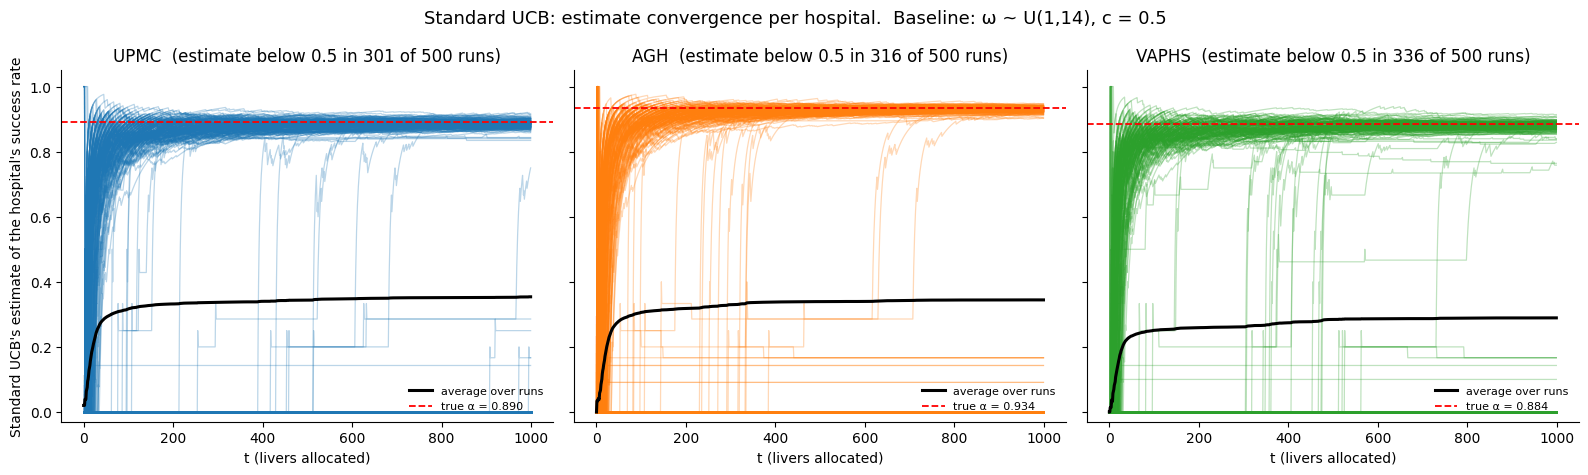

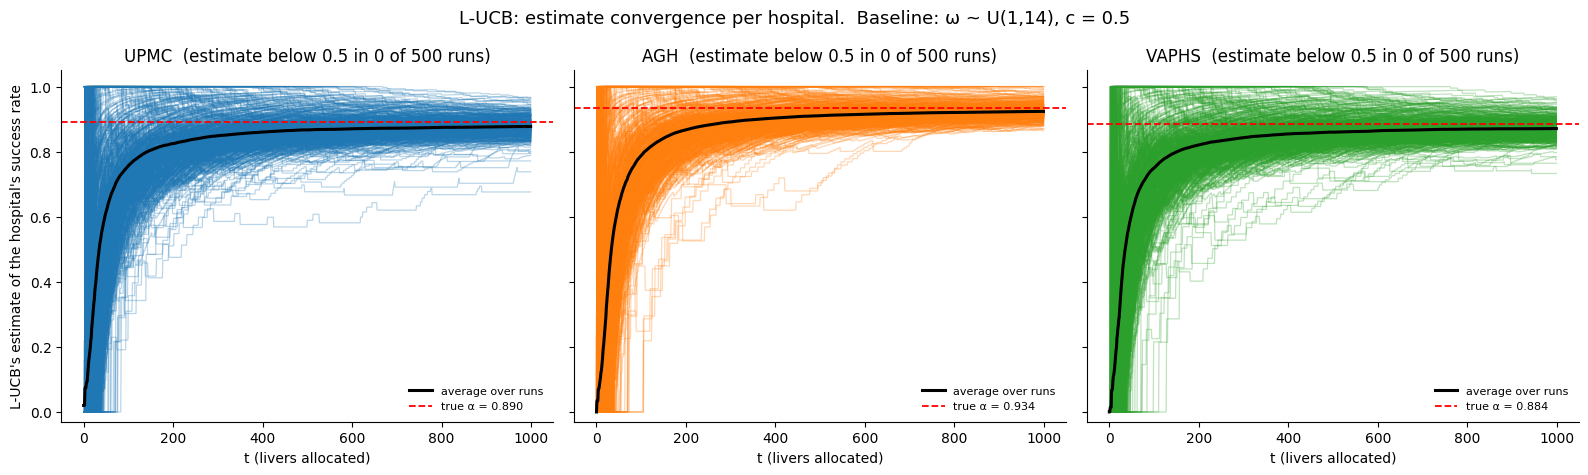

In [4]:
fig_estimates("baseline", "Vanilla UCB")
fig_estimates("baseline", "L-UCB")

Standard: The black lines do not converge to the true values of alpha estimates. Over 300 out of 500 MC simulation, standard UCB ended up with an estimate below 0.5 for UPMC, AGH, and VAPHS, respectively.

LUCB: Across 500 simulation runs, L-UCB consistently converged toward the true hospital success rates for UPMC, AGH, and VAPHS, with zero runs producing an estimate below 0.5. L-UCB produces stable estimates across all three hospitals.

### Figure 2 (baseline). Cumulative regret: Standard UCB vs. L-UCB
Left: average cumulative regret with a 95% band. Right: final regret of every run, which shows the spread the average hides.

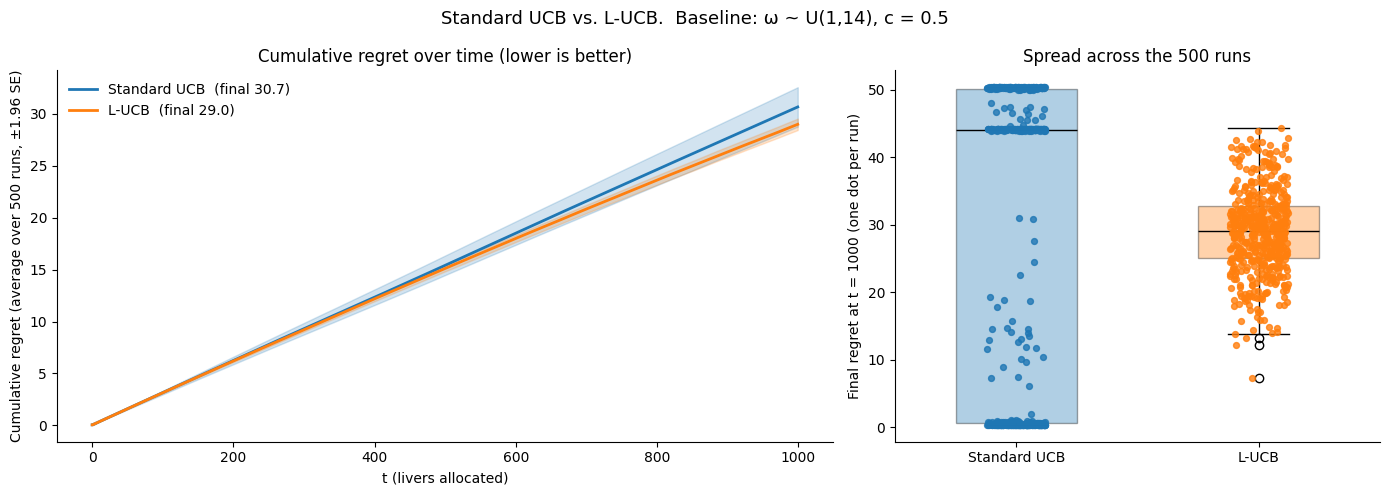

In [5]:
fig_regret("baseline")

L-UCB substantially reduces the variability and worst-case behavior of allocation performance while modestly reducing average regret.

## 3.  Sensitivity analysis for $\omega$ and $c$
Each parameter is varied on its own, so you can judge how robust the results are to that parameter. OPTN could not know the true $\omega$, so in every analysis below **L-UCB assumes one value (`OMEGA_ASSUMED`) while the world's $\omega$ varies**. A difference is called significant when it is more than 1.96 standard errors from zero (paired by run).
- **A. $\omega$ only.** The world's $\omega$ = 1..20 and L-UCB assumes several fixed values, with $c$ held at `C_REF` (0.5).
- **B. $c$ only.** $c=0.1..2.0$, with the world's $\omega\sim U(1,14)$ per program (as in the baseline).
- **C. $c\times\omega$ together.** A grid of $c$ and the world's $\omega$.

The sensitivity parts use no starting experience.

In [6]:
C_REF = 0.5      # reference c held fixed in the omega sweep (0.5 = the c used in both parameter sets)
# ---- shared helper: one paired run of both algorithms ----
OMEGA_ASSUMED = 7.5     # the one omega that L-UCB ASSUMES for every program in B and C (midpoint of the 1-14 range); Standard UCB does not use omega
def assumed():          # omega_alg argument: what L-UCB believes (all programs the same)
    return np.full(K_real, float(OMEGA_ASSUMED))

def paired_final(omega_prog, c, seed, omega_alg=None):
    # omega_prog = the world's omega; omega_alg = the omega L-UCB assumes (None = L-UCB knows omega_prog)
    out = {}
    for policy in POLICIES:
        r_, _, n_ = simulate(policy, T, true_alpha_real, arm_prog_3, omega_prog, np.random.default_rng(seed), c=c,
                             omega_alg=omega_alg if policy == "L-UCB" else None)
        out[policy] = (r_[-1], n_[best_arm_3] / n_.sum())
    return out

def collect(omega_fn, c, n_runs, seed0, omega_alg=None):
    # Final regret and best-arm share of both algorithms over n_runs paired runs.
    f = {p: [] for p in POLICIES}; sh = {p: [] for p in POLICIES}
    for run in range(n_runs):
        res = paired_final(omega_fn(run), c, seed0 + run, omega_alg)
        for p in POLICIES:
            f[p].append(res[p][0]); sh[p].append(res[p][1])
    f = {p: np.array(v) for p, v in f.items()}
    d = f["Vanilla UCB"] - f["L-UCB"]                                     # > 0 means L-UCB lost less
    return dict(mean={p: f[p].mean() for p in POLICIES}, se={p: f[p].std(ddof=1) / np.sqrt(n_runs) for p in POLICIES},
                sd={p: f[p].std(ddof=1) for p in POLICIES}, share={p: np.mean(sh[p]) for p in POLICIES},
                diff=d.mean(), diff_se=d.std(ddof=1) / np.sqrt(n_runs))

def flag(diff, se):
    return "-" if abs(diff) <= 1.96 * se else ("L-UCB better" if diff > 0 else "Standard better")

def to_table(key_name, keys, res):
    t = pd.DataFrame({key_name: keys,
        "Standard UCB regret": [res[k]["mean"]["Vanilla UCB"] for k in keys], "L-UCB regret": [res[k]["mean"]["L-UCB"] for k in keys],
        "Standard - L-UCB": [res[k]["diff"] for k in keys], "SE": [res[k]["diff_se"] for k in keys],
        "Standard SD": [res[k]["sd"]["Vanilla UCB"] for k in keys], "L-UCB SD": [res[k]["sd"]["L-UCB"] for k in keys],
        "Standard best-arm %": [100 * res[k]["share"]["Vanilla UCB"] for k in keys],
        "L-UCB best-arm %": [100 * res[k]["share"]["L-UCB"] for k in keys]}).round(2)
    t["significant"] = [flag(res[k]["diff"], res[k]["diff_se"]) for k in keys]
    return t

### A. Sensitivity to $\omega$ when $\omega$ is not known
The world's $\omega$ is varied (same for all programs), but **L-UCB must assume one value** for it, so the analysis shows what happens when the assumption is wrong. Standard UCB does not use $\omega$, so it is unchanged. $c$ is held at `C_REF`; there is no starting experience. The line 'L-UCB knows $\omega$' is only a benchmark: the best L-UCB could do if OPTN knew $\omega$.

final regret, c = 0.5, 400 runs per cell, random allocation = 31.6

 true omega  Standard UCB  L-UCB knows omega  L-UCB assumes 3  L-UCB assumes 5  L-UCB assumes 7.5  L-UCB assumes 8  L-UCB assumes 9  L-UCB assumes 10  L-UCB assumes 11  L-UCB assumes 12  L-UCB assumes 13  L-UCB assumes 14  L-UCB assumes 15  L-UCB assumes 16  L-UCB assumes 17  L-UCB assumes 18  L-UCB assumes 19  L-UCB assumes 20
        1.0          20.3               21.6             28.1             30.5               31.6             31.6             31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6
        3.0          25.7               27.3             27.3             29.4               31.0             31.3             31.6              31.6              31.6              31.6              31.6              31.6              31.6              31.6              3

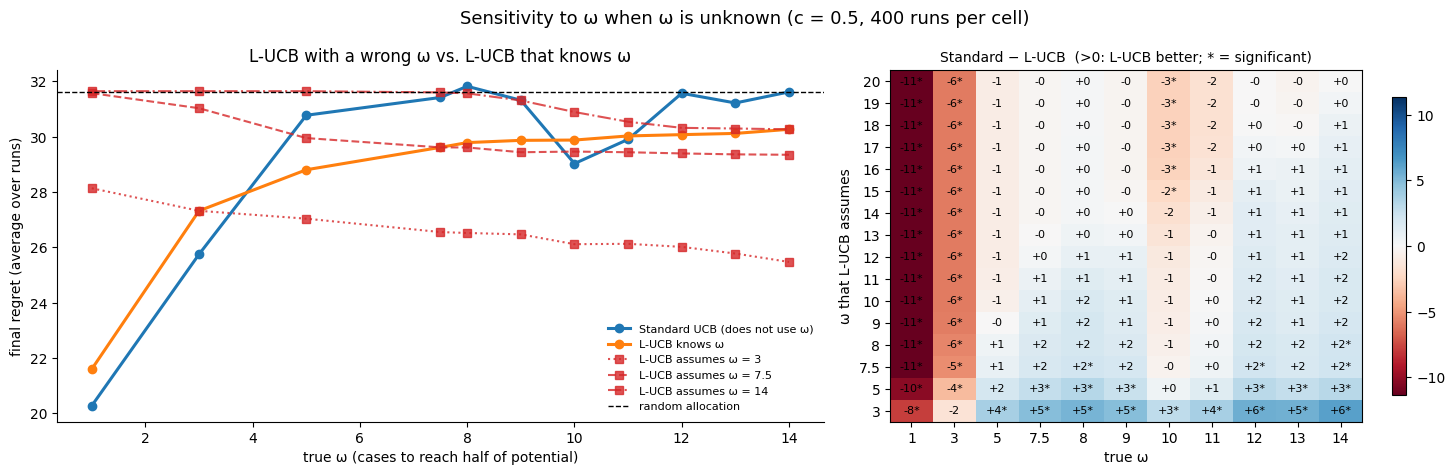

In [7]:
# Sensitivity to omega when omega is NOT known: the world's omega is varied, L-UCB has to ASSUME a value.
TRUE_OMEGAS    = [1, 3, 5, 7.5, 8, 9, 10, 11, 12, 13, 14]       # the world's omega (same for all programs)
ASSUMED_OMEGAS = [3, 5, 7.5, 8, 9,10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]  
N_RUNS_UNK     = 400                             # runs per cell (paired: same rewards for every algorithm)

def paired_unknown(om_true, seed):
    w = np.full(K_real, float(om_true)); out = {}
    out["std"]   = simulate("Vanilla UCB", T, true_alpha_real, arm_prog_3, w, np.random.default_rng(seed), c=C_REF)[0][-1]
    out["known"] = simulate("L-UCB", T, true_alpha_real, arm_prog_3, w, np.random.default_rng(seed), c=C_REF)[0][-1]
    for oa in ASSUMED_OMEGAS:
        out[oa] = simulate("L-UCB", T, true_alpha_real, arm_prog_3, w, np.random.default_rng(seed), c=C_REF,
                           omega_alg=np.full(K_real, float(oa)))[0][-1]
    return out

R = {om: [paired_unknown(om, 110_000 + r) for r in range(N_RUNS_UNK)] for om in TRUE_OMEGAS}
keys = ["std", "known"] + ASSUMED_OMEGAS
mean = {k: np.array([np.mean([x[k] for x in R[om]]) for om in TRUE_OMEGAS]) for k in keys}
diff = {oa: np.array([np.mean([x["std"] - x[oa] for x in R[om]]) for om in TRUE_OMEGAS]) for oa in ASSUMED_OMEGAS}
dse  = {oa: np.array([np.std([x["std"] - x[oa] for x in R[om]], ddof=1) / np.sqrt(N_RUNS_UNK) for om in TRUE_OMEGAS]) for oa in ASSUMED_OMEGAS}
rand = T * (true_alpha_real.max() - true_alpha_real.mean())

tab = pd.DataFrame({"true omega": TRUE_OMEGAS, "Standard UCB": mean["std"], "L-UCB knows omega": mean["known"],
                    **{f"L-UCB assumes {oa:g}": mean[oa] for oa in ASSUMED_OMEGAS}}).round(1)
print(f"final regret, c = {C_REF}, {N_RUNS_UNK} runs per cell, random allocation = {rand:.1f}\n"); print(tab.to_string(index=False))
tab.to_csv("sensitivity_omega_unknown.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
ax.plot(TRUE_OMEGAS, mean["std"], "o-", color=COLORS["Vanilla UCB"], lw=2.2, label="Standard UCB (does not use ω)")
ax.plot(TRUE_OMEGAS, mean["known"], "o-", color=COLORS["L-UCB"], lw=2.2, label="L-UCB knows ω")
for oa, ls in zip([3, 7.5, 14], [":", "--", "-."]):
    ax.plot(TRUE_OMEGAS, mean[oa], marker="s", ls=ls, color="tab:red", alpha=0.8, label=f"L-UCB assumes ω = {oa:g}")
ax.axhline(rand, color="black", ls="--", lw=1, label="random allocation")
ax.set_xlabel("true ω (cases to reach half of potential)"); ax.set_ylabel("final regret (average over runs)")
ax.set_title("L-UCB with a wrong ω vs. L-UCB that knows ω"); ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

M = np.array([diff[oa] for oa in ASSUMED_OMEGAS]); S = np.array([dse[oa] for oa in ASSUMED_OMEGAS]); lim = np.abs(M).max()
im = axes[1].imshow(M, cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto", origin="lower")
axes[1].set_xticks(range(len(TRUE_OMEGAS))); axes[1].set_xticklabels(TRUE_OMEGAS)
axes[1].set_yticks(range(len(ASSUMED_OMEGAS))); axes[1].set_yticklabels([f"{a:g}" for a in ASSUMED_OMEGAS])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        axes[1].text(j, i, f"{M[i, j]:+.0f}" + ("*" if abs(M[i, j]) > 1.96 * S[i, j] else ""), ha="center", va="center", fontsize=8)
axes[1].set_xlabel("true ω"); axes[1].set_ylabel("ω that L-UCB assumes")
axes[1].set_title("Standard − L-UCB  (>0: L-UCB better; * = significant)", fontsize=10); plt.colorbar(im, ax=axes[1], shrink=0.85)
fig.suptitle(f"Sensitivity to ω when ω is unknown (c = {C_REF}, {N_RUNS_UNK} runs per cell)", fontsize=13)
plt.tight_layout(); savefig(fig, "fig_omega_unknown.png"); plt.show()

### B. Sensitivity to $c$ only (0.1 to 2.0), $\omega$ unknown to L-UCB
The world's $\omega$ is drawn $U(1,14)$ per program in every run. L-UCB assumes the same $\omega$ (`OMEGA_ASSUMED`) for every program and never sees the true values. The dashed orange line is L-UCB that is told the true $\omega$, as a reference.

c sweep with world ω ~ U(1, 14), L-UCB assumes ω = 7.5   (T = 1000, 100 runs per c)

   c  Standard UCB regret  L-UCB regret  L-UCB regret (knows omega)  Standard - L-UCB   SE  Standard SD  L-UCB SD  Standard best-arm %  L-UCB best-arm %     significant
0.10                28.70         23.86                       19.51              4.84 1.62        22.85     12.21                38.92             49.74    L-UCB better
0.25                28.70         28.16                       26.44              0.54 1.90        22.85      5.64                38.91             40.74               -
0.50                27.97         29.96                       29.50             -1.99 2.05        22.47      2.82                40.79             36.88               -
0.75                26.49         30.57                       30.51             -4.08 1.76        18.94      1.86                44.36             35.60 Standard better
1.00                25.68         30.82                       30.77   

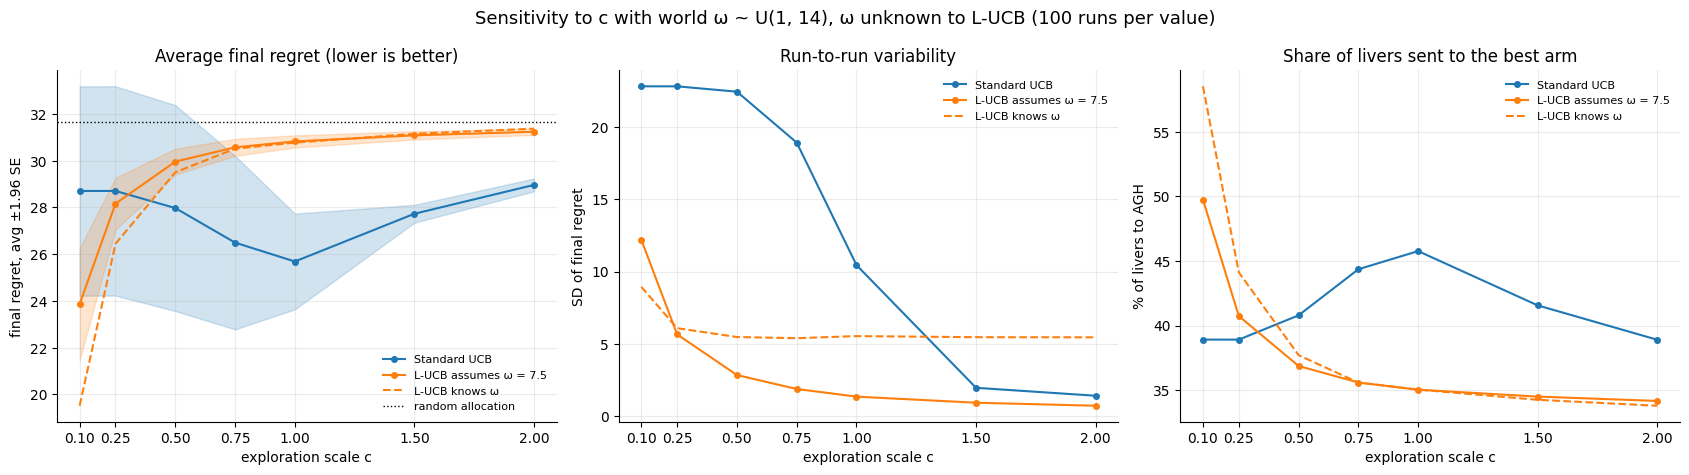

In [8]:
# Robustness of the results to c ALONE when omega is NOT known: the world's omega is drawn as in the baseline (uniform 1-14 per program per run),
# L-UCB assumes OMEGA_ASSUMED for every program, c is swept.
OMEGA_REF  = (1, 14)               # the world's omega: (low, high) = uniform draw, or a single number = fixed
C_GRID     = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
N_RUNS_C   = 100                   # Monte Carlo runs per c value
omega_label = f"world ω ~ U{OMEGA_REF}" if isinstance(OMEGA_REF, tuple) else f"world ω = {OMEGA_REF:g}"
om_fn = lambda run: omega_for_run(OMEGA_REF, run, 80_000)

res_c   = {c_val: collect(om_fn, c_val, N_RUNS_C, 90_000, omega_alg=assumed()) for c_val in C_GRID}   # L-UCB assumes OMEGA_ASSUMED
res_c_k = {c_val: collect(om_fn, c_val, N_RUNS_C, 90_000) for c_val in C_GRID}                          # reference: L-UCB knows omega
tab_c = to_table("c", C_GRID, res_c)
tab_c.insert(3, "L-UCB regret (knows omega)", [res_c_k[c]["mean"]["L-UCB"] for c in C_GRID]); tab_c["L-UCB regret (knows omega)"] = tab_c["L-UCB regret (knows omega)"].round(2)
print(f"c sweep with {omega_label}, L-UCB assumes ω = {OMEGA_ASSUMED:g}   (T = {T}, {N_RUNS_C} runs per c)\n"); print(tab_c.to_string(index=False))
tab_c.to_csv("sensitivity_c.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.array(C_GRID)
for p in POLICIES:
    lab = LABELS[p] if p == "Vanilla UCB" else f"L-UCB assumes ω = {OMEGA_ASSUMED:g}"
    m = np.array([res_c[c]["mean"][p] for c in C_GRID]); se = np.array([res_c[c]["se"][p] for c in C_GRID])
    axes[0].plot(x, m, marker="o", ms=4, color=COLORS[p], label=lab); axes[0].fill_between(x, m - 1.96 * se, m + 1.96 * se, color=COLORS[p], alpha=0.2)
    axes[1].plot(x, [res_c[c]["sd"][p] for c in C_GRID], marker="o", ms=4, color=COLORS[p], label=lab)
    axes[2].plot(x, [100 * res_c[c]["share"][p] for c in C_GRID], marker="o", ms=4, color=COLORS[p], label=lab)
kn = "L-UCB"      # dashed reference: L-UCB told the true omega
axes[0].plot(x, [res_c_k[c]["mean"][kn] for c in C_GRID], ls="--", color=COLORS[kn], label="L-UCB knows ω")
axes[1].plot(x, [res_c_k[c]["sd"][kn] for c in C_GRID], ls="--", color=COLORS[kn], label="L-UCB knows ω")
axes[2].plot(x, [100 * res_c_k[c]["share"][kn] for c in C_GRID], ls="--", color=COLORS[kn], label="L-UCB knows ω")
axes[0].axhline(T * (true_alpha_real.max() - true_alpha_real.mean()), color="black", ls=":", lw=1, label="random allocation")
axes[0].set_title("Average final regret (lower is better)"); axes[0].set_ylabel("final regret, avg ±1.96 SE")
axes[1].set_title("Run-to-run variability"); axes[1].set_ylabel("SD of final regret")
axes[2].set_title("Share of livers sent to the best arm"); axes[2].set_ylabel("% of livers to AGH")
for ax in axes:
    ax.set_xlabel("exploration scale c"); ax.set_xticks(x); ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"Sensitivity to c with {omega_label}, ω unknown to L-UCB ({N_RUNS_C} runs per value)", fontsize=13)
plt.tight_layout(); savefig(fig, "fig6_c_sensitivity.png"); plt.show()

> **Out of date after this change.** The text below was written for the run in which L-UCB was *told the true ω*. Re-read it against the new B output (L-UCB now assumes `OMEGA_ASSUMED`) and rewrite it.

Sensitivity analysis for varying the exploration scale c from 0.10 to 2.00 (ω ~ U(1,14), no starting experience, T = 1,000 livers, 500 Monte Carlo runs per value). 

The two algorithms preferred different values of c: L-UCB had its lowest average final regret at c = 0.10 (about 19.4), Standard UCB at c ≈ 1.0 (about 24.8). 
Compared at each algorithm's own best c, L-UCB's regret was about 22% lower; at c = 0.10, where both are run at the same c, it was about 35% lower (19.4 vs 29.6). 

The advantage does not hold across the range.

at c ≥ 0.5 L-UCB's regret approaches that of random allocation (about 31.6) and Standard UCB is lower for c ≥ 0.75. 

For c ≤ 1.0, L-UCB's run-to-run variability was lower (SD about 5–9 vs about 10–22), which for Standard UCB reflects runs that lock onto a single program; 

at c ≥ 1.5 Standard UCB's variability was lower because it explores almost uniformly.

## 4. Part 3: Fixed parameters, same $\omega$ and $c$, with starting experience
Same model, same programs, same random-number seeds as Part 1: $\omega\sim U(1,14)$ per program and $c=0.5$. The only change is that each program starts with the split transplants it has already done (from STAR): UPMC 30, AGH 0, VAPHS 9. Because $g_\omega(s+s_0)=g_{\omega-s_0}(s)$, UPMC (30) is already past its learning curve for any $\omega\le14$, VAPHS (9) is partly through it, and AGH, the best arm, starts from zero. Both algorithms get the same draws, so differences from Part 1 come from $s_0$ alone.

In [9]:
run_setting("fixed")

Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9]   (T = 1000, runs = 500, best arm = AGH)

Standard UCB final regret   41.7  [95% of runs: 15.7-48.5] | share of pulls to best arm 11.1%
L-UCB        final regret   13.7  [95% of runs: 6.1-26.7] | share of pulls to best arm 71.3%

Standard UCB average pulls: UPMC 525, AGH 111, VAPHS 365
L-UCB        average pulls: UPMC 126, AGH 713, VAPHS 161

Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9]: Standard - L-UCB final regret = +28.0 (SE 0.6) -> L-UCB has significantly lower average regret
                                                          spread of final regret across runs (SD): Standard 10.4 vs L-UCB 5.6; L-UCB better in 93% of runs


### Figure 1 (fixed). Estimate convergence per hospital

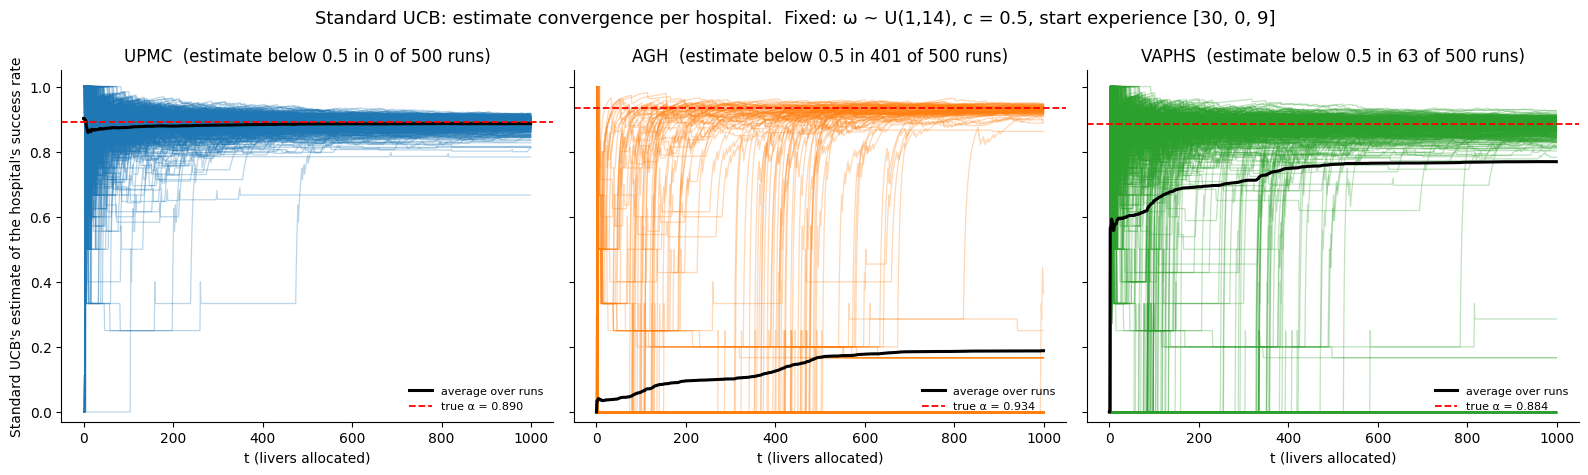

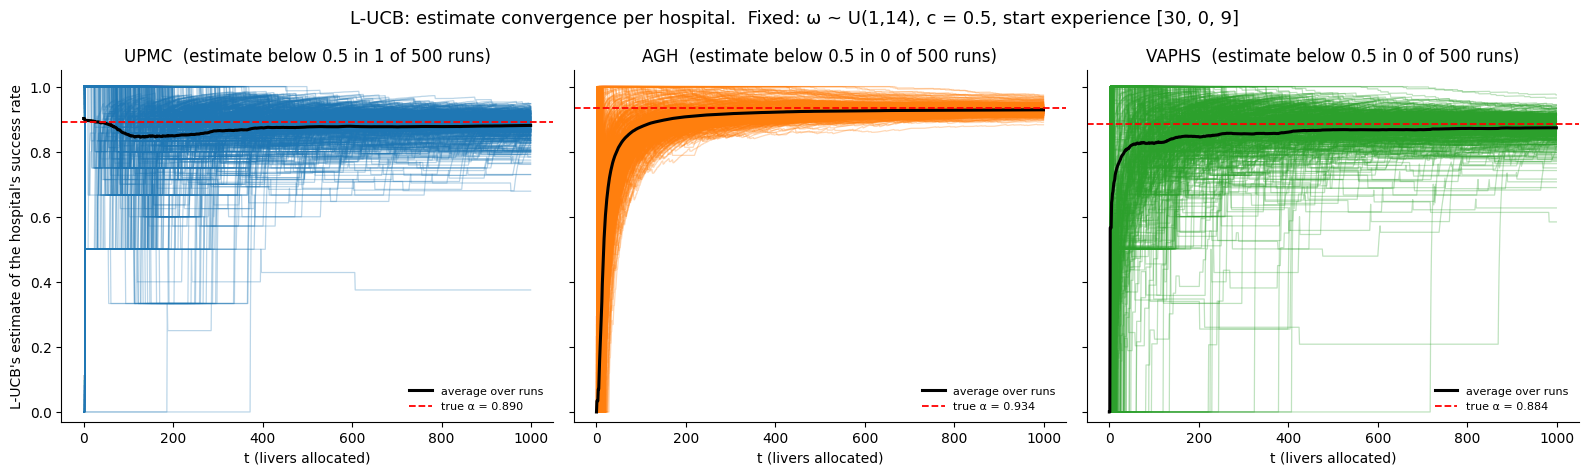

In [10]:
fig_estimates("fixed", "Vanilla UCB")
fig_estimates("fixed", "L-UCB")

The starting experience makes the programs look different at the start, even though their potentials are close (0.890, 0.934, 0.884). Standard UCB cannot tell "inexperienced" from "worse," so it misjudges the best program in most runs. L-UCB can, and that is where its regret advantage in this setting comes from (13.7 vs 41.7).

### Figure 2 (fixed). Cumulative regret: Standard UCB vs. L-UCB

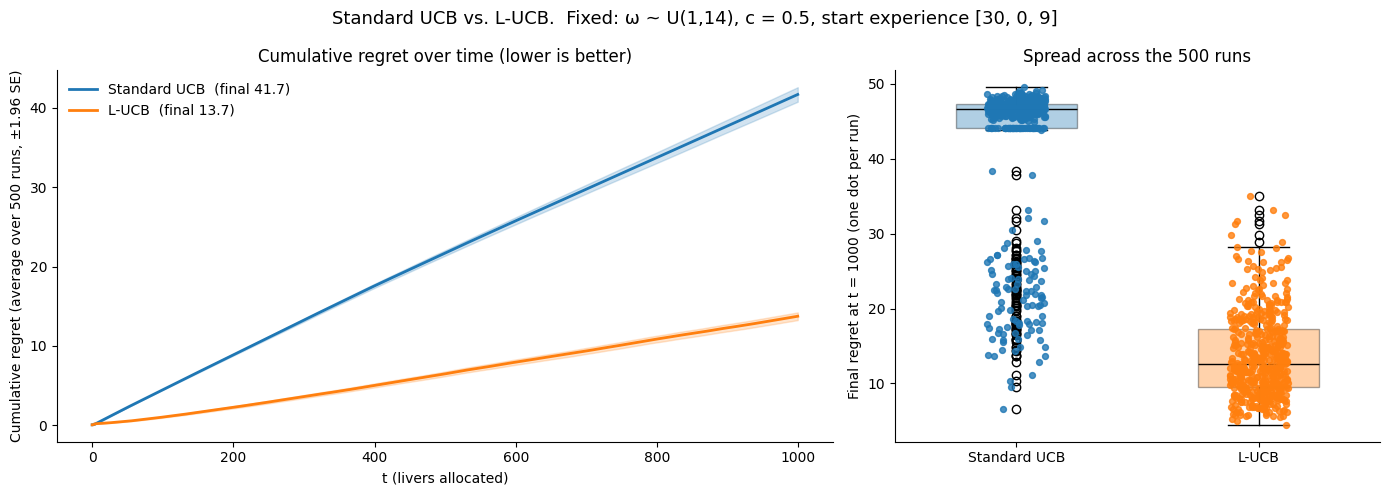

In [11]:
fig_regret("fixed")

Heterogeneous starting experience substantially increases the value of L-UCB. With starting experience of 30, 0, and 9 cases for UPMC, AGH, and VAPHS, respectively, L-UCB reduced 1,000-allocation regret by 67% compared with Standard UCB (13.7 vs. 41.7).

The reason is that Standard UCB observes current performance but does not distinguish poor performance caused by lack of experience from intrinsically low hospital quality. L-UCB explicitly accounts for the learning curve and starting experience, allowing it to identify the underlying quality more effectively.

## 5. Comparison: baseline vs. fixed parameters
Same algorithms, same seeds, same $\omega$ draws and same $c$; only the starting experience changes. Note that regret is measured against the same best arm (AGH) in both settings, so the levels are comparable.

                                                 setting    algorithm  mean final regret  SD across runs 5th-95th pct share to best arm
                          Baseline: ω ~ U(1,14), c = 0.5 Standard UCB               30.7            21.7         0-50             34.9%
                          Baseline: ω ~ U(1,14), c = 0.5        L-UCB               29.0             6.3        19-40             38.8%
Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9] Standard UCB               41.7            10.4        18-48             11.1%
Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9]        L-UCB               13.7             5.6         7-24             71.3%

Baseline: ω ~ U(1,14), c = 0.5: Standard - L-UCB final regret = +1.7 (SE 1.2) -> no significant difference in average regret
                                spread of final regret across runs (SD): Standard 21.7 vs L-UCB 6.3; L-UCB better in 63% of runs
Fixed: ω ~ U(1,14), c = 0.5, start experience [30, 0, 9]: Standar

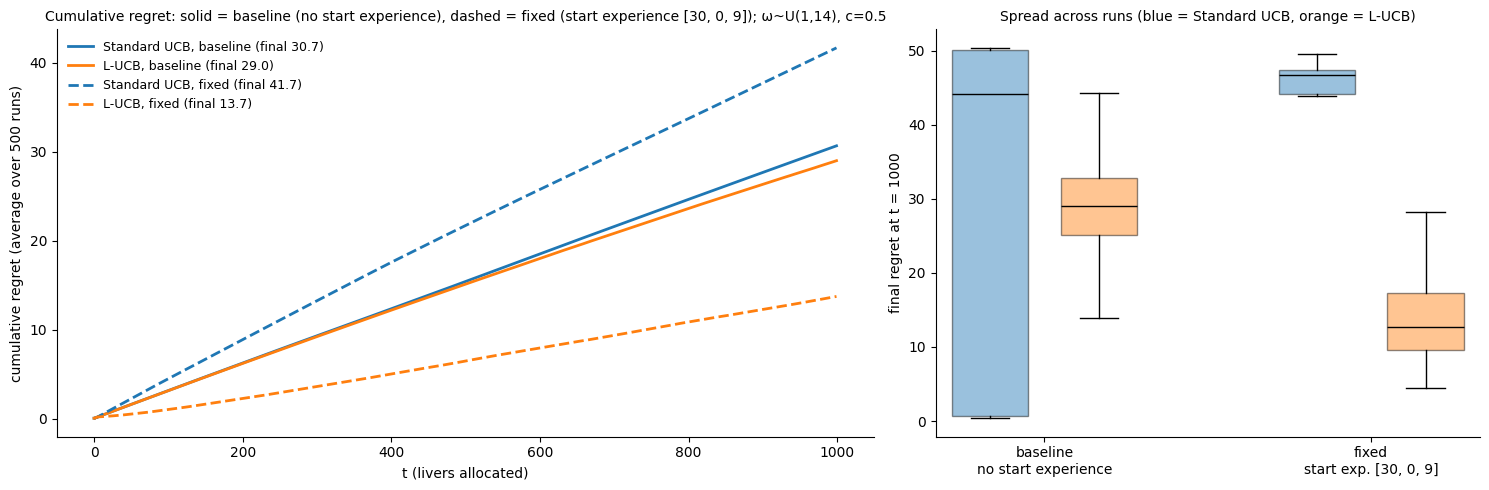

In [12]:
rows = []
for key in ["baseline", "fixed"]:
    for policy in POLICIES:
        final = RESULTS[key]["reg"][policy][:, -1]
        share = np.mean([p[best_arm_3] / p.sum() for p in RESULTS[key]["pul"][policy]])
        rows.append({"setting": SETTINGS[key]["label"], "algorithm": LABELS[policy], "mean final regret": round(final.mean(), 1),
                     "SD across runs": round(final.std(ddof=1), 1), "5th-95th pct": f"{np.percentile(final, 5):.0f}-{np.percentile(final, 95):.0f}",
                     "share to best arm": f"{share:.1%}"})
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False)); print()
for key in ["baseline", "fixed"]:
    compare(RESULTS[key]["reg"], SETTINGS[key]["label"])
comparison.to_csv("comparison_baseline_vs_fixed.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.5, 1]})
style = {"baseline": "-", "fixed": "--"}
for key in ["baseline", "fixed"]:
    for policy in POLICIES:
        m = RESULTS[key]["reg"][policy].mean(axis=0)
        axes[0].plot(m, color=COLORS[policy], ls=style[key], lw=2, label=f"{LABELS[policy]}, {key} (final {m[-1]:.1f})")
axes[0].set_xlabel("t (livers allocated)"); axes[0].set_ylabel(f"cumulative regret (average over {N_RUNS} runs)")
axes[0].set_title("Cumulative regret: solid = baseline (no start experience), dashed = fixed (start experience [30, 0, 9]); ω~U(1,14), c=0.5", fontsize=10)
axes[0].legend(frameon=False, fontsize=9); axes[0].spines[["top", "right"]].set_visible(False)

data, pos, cols = [], [], []
for g_i, key in enumerate(["baseline", "fixed"]):
    for k_i, policy in enumerate(POLICIES):
        data.append(RESULTS[key]["reg"][policy][:, -1]); pos.append(g_i * 3 + k_i + 1); cols.append(COLORS[policy])
bp = axes[1].boxplot(data, positions=pos, widths=0.7, patch_artist=True, medianprops=dict(color="black"), showfliers=False)
for patch, c_ in zip(bp["boxes"], cols):
    patch.set_facecolor(c_); patch.set_alpha(0.45)
axes[1].set_xticks([1.5, 4.5]); axes[1].set_xticklabels(["baseline\nno start experience", "fixed\nstart exp. [30, 0, 9]"])
axes[1].set_ylabel(f"final regret at t = {T}"); axes[1].set_title("Spread across runs (blue = Standard UCB, orange = L-UCB)", fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); savefig(fig, "fig8_baseline_vs_fixed.png"); plt.show()

The value of L-UCB becomes substantially larger when programs enter the allocation process with heterogeneous prior experience. In the baseline scenario with no starting experience, Standard UCB and L-UCB had similar final regret (30.7 vs. 29.0). When starting experience differed across programs (30, 0, and 9 cases), Standard UCB's regret increased to 41.7, whereas L-UCB's regret decreased to 13.7. This suggests that explicitly accounting for prior experience allows L-UCB to avoid confusing differences in learning stage with differences in underlying hospital quality.

### 5b. The same headline numbers when L-UCB does not know $\omega$
Parts 1 and 3 above tell L-UCB the true $\omega$ of each run. Here the same runs (same $\omega$ draws, same rewards, $s_0$ as in each parameter set) are repeated with L-UCB **assuming** one $\omega$ for every program (`OMEGA_ASSUMED` and two other guesses). Standard UCB does not use $\omega$, so its number does not change. A difference is significant when it is more than 1.96 SE from zero (paired).

In [13]:
ASSUME_LIST = [3, OMEGA_ASSUMED, 14]
rows = []
for key in ["baseline", "fixed"]:
    s = SETTINGS[key]; R5 = {k: [] for k in ["std", "known"] + ASSUME_LIST}
    for run in range(N_RUNS):
        om = omega_for_run(s["omega"], run, 1000)
        mk = lambda: np.random.default_rng(50_000 + run)
        R5["std"].append(simulate("Vanilla UCB", T, true_alpha_real, arm_prog_3, om, mk(), c=s["c"], s0=s.get("s0"))[0][-1])
        R5["known"].append(simulate("L-UCB", T, true_alpha_real, arm_prog_3, om, mk(), c=s["c"], s0=s.get("s0"))[0][-1])
        for oa in ASSUME_LIST:
            R5[oa].append(simulate("L-UCB", T, true_alpha_real, arm_prog_3, om, mk(), c=s["c"], s0=s.get("s0"),
                                   omega_alg=np.full(K_real, float(oa)))[0][-1])
    R5 = {k: np.array(x) for k, x in R5.items()}
    for name in ["known"] + ASSUME_LIST:
        d = R5["std"] - R5[name]; se = d.std(ddof=1) / np.sqrt(N_RUNS)
        rows.append({"setting": key, "L-UCB version": "knows true omega" if name == "known" else f"assumes omega = {name:g}",
                     "Standard regret": R5["std"].mean(), "L-UCB regret": R5[name].mean(), "L-UCB SD": R5[name].std(ddof=1),
                     "Standard - L-UCB": d.mean(), "SE": se,
                     "winner": "-" if abs(d.mean()) <= 1.96 * se else ("L-UCB" if d.mean() > 0 else "Standard")})
tab_5b = pd.DataFrame(rows).round(2)
print(f"final regret at T = {T}, {N_RUNS} runs, random allocation = {T * (true_alpha_real.max() - true_alpha_real.mean()):.1f}\n")
print(tab_5b.to_string(index=False)); tab_5b.to_csv("comparison_unknown_omega.csv", index=False)

final regret at T = 1000, 500 runs, random allocation = 31.6

 setting       L-UCB version  Standard regret  L-UCB regret  L-UCB SD  Standard - L-UCB   SE winner
baseline    knows true omega            30.68         29.01      6.30              1.67 1.18      -
baseline   assumes omega = 3            30.68         26.59      3.11              4.09 0.91  L-UCB
baseline assumes omega = 7.5            30.68         30.16      2.94              0.52 0.87      -
baseline  assumes omega = 14            30.68         31.27      1.41             -0.59 0.94      -
   fixed    knows true omega            41.70         13.74      5.56             27.96 0.63  L-UCB
   fixed   assumes omega = 3            41.70         15.96      4.46             25.74 0.45  L-UCB
   fixed assumes omega = 7.5            41.70          9.16      3.17             32.54 0.42  L-UCB
   fixed  assumes omega = 14            41.70         18.55      2.78             23.15 0.45  L-UCB


## 6. Robustness checks
Does the baseline-vs-fixed conclusion survive when the assumptions are changed? Every check is run for **both parameter sets** (both: $\omega\sim U(1,14)$, $c=0.5$; baseline has no starting experience, fixed has $s_0=[30,0,9]$), paired by run (same $\omega$, same $\alpha$ draw and same reward stream for both algorithms). Each table reports the final regret of each algorithm, the paired difference *Standard − L-UCB* (positive = L-UCB better) with its standard error, and the **random-allocation regret**: what you would lose by sending every liver to a random program ($T$ times the average gap, about 31.6 for the three programs at $T=1000$). An algorithm that is not clearly below that line has learned almost nothing.

| Check | What changes |
|---|---|
| 6.1 | the true $\alpha$ values: drawn from their uncertainty; and each of UPMC, AGH, VAPHS made the best program |
| 6.2 | horizon $T=200,500,1000,3600$ |
| 6.3 | $\omega$ different by program (the parameter set's own starting experience is kept) |

`N_RB` runs per cell (default 100) keeps the whole section to a few minutes; raise it for final numbers.

**L-UCB does not know $\omega$ here.** In every check below the world's $\omega$ generates the rewards, but L-UCB assumes the single value `OMEGA_ASSUMED` (7.5, the middle of 1-14) for every program. Set `RB_LUCB_ASSUMES = False` in the first code cell of this section to give L-UCB the true $\omega$ instead (the earlier version of this section). Starting experience $s_0$ is observed data and stays known to both algorithms.

In [14]:
N_RB    = 100            # Monte Carlo runs per cell in every robustness check
SEED_RB = 300_000        # same reward stream for both algorithms inside a run
ALL_RB  = []             # every summary table is collected here for the verdict table in 6.4
RB_LUCB_ASSUMES = True   # True: L-UCB assumes OMEGA_ASSUMED for every program (realistic); False: L-UCB is told the true omega (earlier version)

def g_fun(omega, s):
    # Logistic learning curve (g = 0.5 at s = omega).
    return 1.0 / (1.0 + np.exp(-(s - omega)))

def simulate_rb(policy, T, alpha, omega_world, rng, c, s0=None, omega_alg=None):
    # Same algorithms as simulate(), for 3 arms = 3 programs.
    #   alpha        true full potential of each program
    #   omega_world  the world's omega for each program (generates the rewards)
    #   omega_alg    the omega L-UCB ASSUMES for each program (None = L-UCB is told omega_world)
    #   s0           cases each program has already done at t = 0 (known to both algorithms; it is NOT part of omega)
    K = len(alpha)
    n = np.zeros(K); ok = np.zeros(K); w_sum = np.zeros(K); inv_g2 = np.zeros(K)
    s = np.zeros(K) if s0 is None else np.asarray(s0, float).copy()
    start = np.tile(np.arange(K), M_INIT); best = alpha.max(); cum = 0.0
    for t in range(1, T + 1):
        if t <= len(start):
            a = int(start[t - 1])
        else:
            if policy == "Vanilla UCB":
                est, n_eff = ok / np.maximum(n, 1), n
            else:
                est, n_eff = np.clip(w_sum / np.maximum(n, 1), 0, 1), np.maximum(n, 1) ** 2 / np.maximum(inv_g2, 1e-9)
            a = int(np.argmax(est + c * np.sqrt(2 * np.log(t) / np.maximum(n_eff, 1e-6))))
        g_s = g_fun(omega_world[a], s[a])
        r = rng.binomial(1, alpha[a] * g_s)
        g_alg = g_s if omega_alg is None else g_fun(omega_alg[a], s[a])      # the g that L-UCB believes in
        g_f = max(g_alg, G_FLOOR)
        n[a] += 1; ok[a] += r; w_sum[a] += r / g_f; inv_g2[a] += (1.0 / g_f) ** 2; s[a] += 1
        cum += best - alpha[a]
    return cum, n

def rb_compare(setting, label, n_runs=None, T_run=None, alpha_fn=None, omega_fn=None, **kw):
    # Paired runs of both algorithms for one parameter set ("baseline" / "fixed") and one scenario.
    # alpha_fn(run) -> alpha vector;  omega_fn(run) -> omega vector;  s0 defaults to the parameter set's own starting experience.
    s_ = SETTINGS[setting]; n_runs = N_RB if n_runs is None else n_runs; T_run = T if T_run is None else T_run
    kw.setdefault("s0", s_.get("s0"))
    rows = []
    for run in range(n_runs):
        alpha = true_alpha_real if alpha_fn is None else alpha_fn(run)
        om = omega_for_run(s_["omega"], run, 1000) if omega_fn is None else omega_fn(run)
        for policy in POLICIES:
            oa = np.full(len(alpha), float(OMEGA_ASSUMED)) if (RB_LUCB_ASSUMES and policy == "L-UCB") else None
            cum, n = simulate_rb(policy, T_run, alpha, om, np.random.default_rng(SEED_RB + run), s_["c"], omega_alg=oa, **kw)
            b = int(np.argmax(alpha))
            rows.append(dict(setting=setting, scenario=label, run=run, best=b, policy=policy, regret=cum,
                             share=n[b] / n.sum(), random_regret=T_run * (alpha.max() - alpha.mean())))
    return pd.DataFrame(rows)
def summ(df, by=("setting", "scenario")):
    out = []
    for key, g in df.groupby(list(by), sort=False):
        a = g[g.policy == "Vanilla UCB"].sort_values("run"); b = g[g.policy == "L-UCB"].sort_values("run")
        d = a.regret.values - b.regret.values; k = len(d)
        se = d.std(ddof=1) / np.sqrt(k) if k > 1 else np.nan
        row = dict(zip(by, key if isinstance(key, tuple) else (key,)))
        row.update({"runs": k, "Standard regret": a.regret.mean(), "L-UCB regret": b.regret.mean(), "Standard - L-UCB": d.mean(), "SE": se,
                    "Standard SD": a.regret.std(ddof=1) if k > 1 else np.nan, "L-UCB SD": b.regret.std(ddof=1) if k > 1 else np.nan,
                    "Standard best-arm %": 100 * a.share.mean(), "L-UCB best-arm %": 100 * b.share.mean(),
                    "random-allocation regret": a.random_regret.mean(),
                    "Standard / random": a.regret.mean() / a.random_regret.mean(), "L-UCB / random": b.regret.mean() / b.random_regret.mean(),
                    "winner": "-" if (k < 2 or abs(d.mean()) <= 1.96 * se) else ("L-UCB" if d.mean() > 0 else "Standard")})
        out.append(row)
    return pd.DataFrame(out).round(2)

def bars(tab, scen_col, title, fname, scen_order=None):
    # One panel per parameter set: mean final regret of both algorithms in every scenario, with the random-allocation line.
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
    for ax, key in zip(axes, ["baseline", "fixed"]):
        d = tab[tab.setting == key]; d = d.set_index(scen_col).loc[scen_order] if scen_order is not None else d.set_index(scen_col)
        x = np.arange(len(d)); w = 0.38
        se_s = d["Standard SD"] / np.sqrt(d["runs"]); se_l = d["L-UCB SD"] / np.sqrt(d["runs"])
        ax.bar(x - w / 2, d["Standard regret"], w, yerr=1.96 * se_s, color=COLORS["Vanilla UCB"], alpha=0.8, label=LABELS["Vanilla UCB"], capsize=2)
        ax.bar(x + w / 2, d["L-UCB regret"], w, yerr=1.96 * se_l, color=COLORS["L-UCB"], alpha=0.8, label=LABELS["L-UCB"], capsize=2)
        for xi, rr in zip(x, d["random-allocation regret"]):
            ax.hlines(rr, xi - 0.45, xi + 0.45, color="black", ls="--", lw=1.2)
        ax.plot([], [], color="black", ls="--", label="random allocation")
        ax.set_xticks(x); ax.set_xticklabels([str(i) for i in d.index], rotation=20, ha="right", fontsize=8)
        ax.set_title(SETTINGS[key]["label"], fontsize=11); ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel("final regret (mean ±1.96 SE)"); axes[0].legend(frameon=False, fontsize=9)
    fig.suptitle(title, fontsize=13); plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

### 6.1 Uncertainty in $\alpha$, and each program as the true best
The SRTR survival rates are estimates from a limited number of transplants. If program $a$ had $n_a$ transplants and an observed 1-year survival $\hat\alpha_a$, a simple posterior for its true survival is $\mathrm{Beta}(\hat\alpha_a n_a+1,\;(1-\hat\alpha_a)n_a+1)$. Each run draws a fresh $\alpha$ vector from it, so the "best" program changes from run to run. **Replace `ALPHA_N` with the transplant counts printed in each program's PSR**; the sweep over `N_LIST` shows the effect without needing them exactly (a smaller $n$ means a noisier $\alpha$).

Two parts: (a) swap which program has the best $\alpha$ (the same three values, reassigned); (b) draw $\alpha$ at random and report the results *by which program turned out best*.

(a) which program is truly best

 setting             scenario  runs  Standard regret  L-UCB regret  Standard - L-UCB   SE  Standard best-arm %  L-UCB best-arm %  random-allocation regret  Standard / random  L-UCB / random   winner
baseline AGH best (main case)   100            26.53         29.78             -3.26 2.02                43.55             37.18                     31.63               0.84            0.94        -
baseline            UPMC best   100            30.69         30.16              0.54 1.95                34.35             36.34                     31.63               0.97            0.95        -
baseline           VAPHS best   100            34.40         30.16              4.24 1.85                27.73             36.46                     31.63               1.09            0.95    L-UCB
   fixed AGH best (main case)   100            41.60          9.36             32.24 0.92                11.05             80.15                     31.63               1.

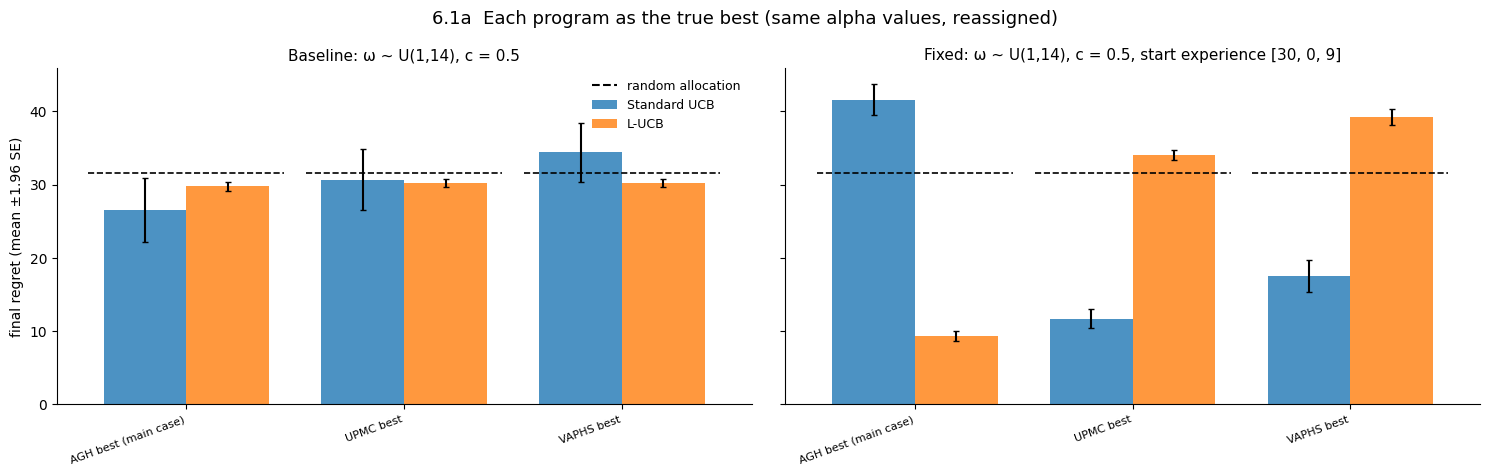


(b) alpha drawn from its uncertainty (all runs)

 setting     scenario  runs  Standard regret  L-UCB regret  Standard - L-UCB   SE  Standard best-arm %  L-UCB best-arm %  random-allocation regret  Standard / random  L-UCB / random   winner
baseline  n = 50 each   200            32.07         36.62             -4.56 2.34                42.53             38.50                     42.64               0.75            0.86        -
baseline n = 100 each   200            28.82         32.37             -3.56 1.96                43.08             38.05                     36.44               0.79            0.89        -
baseline n = 200 each   200            26.95         30.38             -3.43 1.72                43.88             37.88                     33.50               0.80            0.91 Standard
baseline n = 400 each   200            26.79         30.05             -3.26 1.59                42.18             37.35                     32.54               0.82            0.92 Stan

In [15]:
ALPHA_N = None                       # e.g. [180, 60, 45] = adult transplants of UPMC, AGH, VAPHS in the PSR window; None = use N_LIST only
N_LIST  = [50, 100, 200, 400]        # transplants per program assumed in the sweep

# (a) make each program the best one (same three alpha values, reassigned)
a_hi, a_mid, a_lo = 0.9344, 0.8901, 0.8838
swap = {"AGH best (main case)": [a_mid, a_hi, a_lo], "UPMC best": [a_hi, a_mid, a_lo], "VAPHS best": [a_mid, a_lo, a_hi]}
df_a = pd.concat([rb_compare(k, lab, alpha_fn=lambda run, v=np.array(v): v) for k in SETTINGS for lab, v in swap.items()])
tab_a = summ(df_a); ALL_RB.append(tab_a.assign(check="6.1a best program"))
print("(a) which program is truly best\n"); print(tab_a.drop(columns=["Standard SD", "L-UCB SD"]).to_string(index=False))
bars(tab_a, "scenario", "6.1a  Each program as the true best (same alpha values, reassigned)", "fig_rb_6_1a_best_program.png", list(swap))

# (b) alpha drawn from its uncertainty, results grouped by which program ended up best
def draw_alpha(n_list):
    n = np.asarray(n_list, float); ah = true_alpha_real
    return lambda run: np.random.default_rng(555 + run).beta(ah * n + 1, (1 - ah) * n + 1)

cases = {f"n = {n} each": [n] * 3 for n in N_LIST}
if ALPHA_N is not None: cases["PSR counts"] = ALPHA_N
df_b = pd.concat([rb_compare(k, lab, n_runs=N_RB * 2, alpha_fn=draw_alpha(nl)) for k in SETTINGS for lab, nl in cases.items()])
tab_b = summ(df_b); ALL_RB.append(tab_b.assign(check="6.1b alpha drawn"))
print("\n(b) alpha drawn from its uncertainty (all runs)\n"); print(tab_b.drop(columns=["Standard SD", "L-UCB SD"]).to_string(index=False))
best_prob = (df_b[df_b.policy == "Vanilla UCB"].groupby(["setting", "scenario"]).best.value_counts(normalize=True).unstack(fill_value=0)
             .rename(columns=dict(enumerate(real_centers))).round(2))
print("\nshare of draws in which each program is the true best:\n"); print(best_prob.loc["baseline"].to_string())
tab_b2 = summ(df_b, by=("setting", "scenario", "best")).assign(best=lambda d: d.best.map(dict(enumerate(real_centers))))
print("\nresults by which program is truly best (n = 100 each, baseline parameters):\n")
print(tab_b2[(tab_b2.setting == "baseline") & (tab_b2.scenario == "n = 100 each")].drop(columns=["Standard SD", "L-UCB SD"]).to_string(index=False))
tab_a.to_csv("robustness_6_1a_best_program.csv", index=False); tab_b.to_csv("robustness_6_1b_alpha_drawn.csv", index=False); tab_b2.to_csv("robustness_6_1b_by_best.csv", index=False)

### 6.2 Horizon $T$
Tang et al. use $T=3600$. Regret grows with $T$, so the table also shows regret as a fraction of the random-allocation regret at the same $T$ (1.0 = no better than random).

 setting scenario  runs  Standard regret  L-UCB regret  Standard - L-UCB   SE  Standard best-arm %  L-UCB best-arm %  random-allocation regret  Standard / random  L-UCB / random winner
baseline  T = 200   100             5.50          6.26             -0.75 0.41                41.49             34.05                      6.33               0.87            0.99      -
baseline  T = 500   100            13.51         15.38             -1.87 1.03                42.46             35.13                     15.82               0.85            0.97      -
baseline T = 1000   100            26.53         29.78             -3.26 2.02                43.55             37.18                     31.63               0.84            0.94      -
baseline T = 3600   100            91.97         89.69              2.28 7.34                45.45             47.34                    113.88               0.81            0.79      -
   fixed  T = 200   100             8.74          1.04              7.70 0.

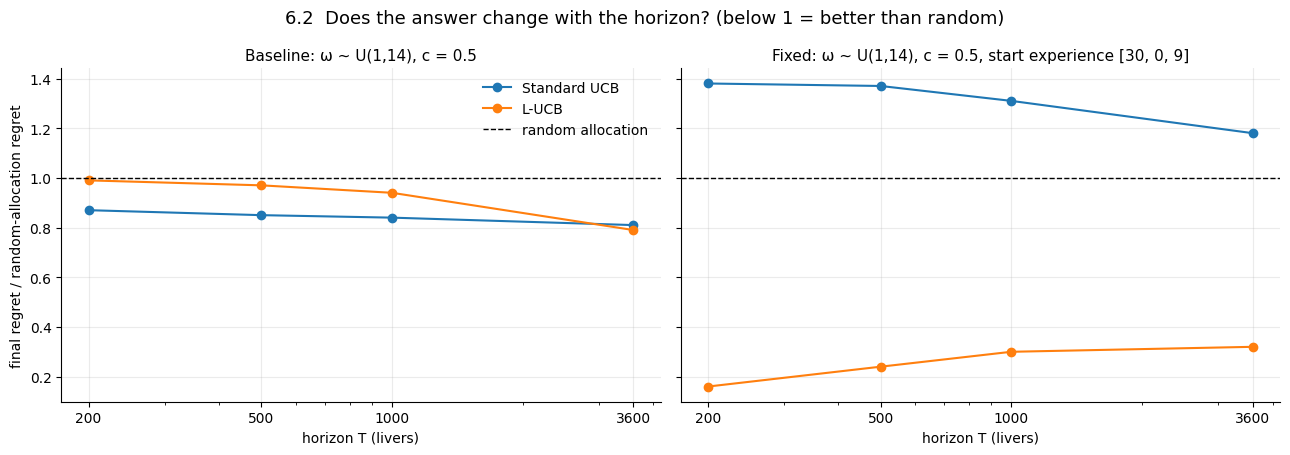

In [16]:
T_LIST = [200, 500, 1000, 3600]
df_t = pd.concat([rb_compare(k, f"T = {Tv}", T_run=Tv) for k in SETTINGS for Tv in T_LIST])
tab_t = summ(df_t); ALL_RB.append(tab_t.assign(check="6.2 horizon"))
print(tab_t.drop(columns=["Standard SD", "L-UCB SD"]).to_string(index=False)); tab_t.to_csv("robustness_6_2_horizon.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, key in zip(axes, SETTINGS):
    d = tab_t[tab_t.setting == key]; x = T_LIST
    ax.plot(x, d["Standard / random"], marker="o", color=COLORS["Vanilla UCB"], label=LABELS["Vanilla UCB"])
    ax.plot(x, d["L-UCB / random"], marker="o", color=COLORS["L-UCB"], label=LABELS["L-UCB"])
    ax.axhline(1, color="black", ls="--", lw=1, label="random allocation")
    ax.set_xscale("log"); ax.set_xticks(x); ax.set_xticklabels(x); ax.set_xlabel("horizon T (livers)"); ax.set_title(SETTINGS[key]["label"], fontsize=11)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(alpha=0.25)
axes[0].set_ylabel("final regret / random-allocation regret"); axes[0].legend(frameon=False)
fig.suptitle("6.2  Does the answer change with the horizon? (below 1 = better than random)", fontsize=13)
plt.tight_layout(); plt.savefig("fig_rb_6_2_horizon.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.3 Different $\omega$ by program
`omega_fn` returns one $\omega$ per program; use it for "program A needs more cases than program B". Each parameter set keeps its own starting experience (baseline: none, fixed: $s_0=[30,0,9]$) and its own $c=0.5$. Starting experience is observed data (STAR), $\omega$ is the unknown parameter, and both algorithms are told $s_0$. In this check the worlds really differ by program, but L-UCB still assumes one common $\omega$ for all of them.

(c and starting experience come from the parameter set; omega comes from the scenario)

 setting                     scenario  runs  Standard regret  L-UCB regret  Standard - L-UCB   SE  Standard best-arm %  L-UCB best-arm %  random-allocation regret  Standard / random  L-UCB / random   winner
baseline  omega ~ U(1,14) (reference)   100            26.53         29.78             -3.26 2.02                43.55             37.18                     31.63               0.84            0.94        -
baseline             common omega = 5   100            27.09         29.95             -2.86 2.18                41.67             36.86                     31.63               0.86            0.95        -
baseline AGH slower: AGH 10, others 3   100            46.85         34.52             12.33 0.26                 0.41             27.18                     31.63               1.48            1.09    L-UCB
baseline AGH faster: AGH 3, others 10   100             0.41         25.27          

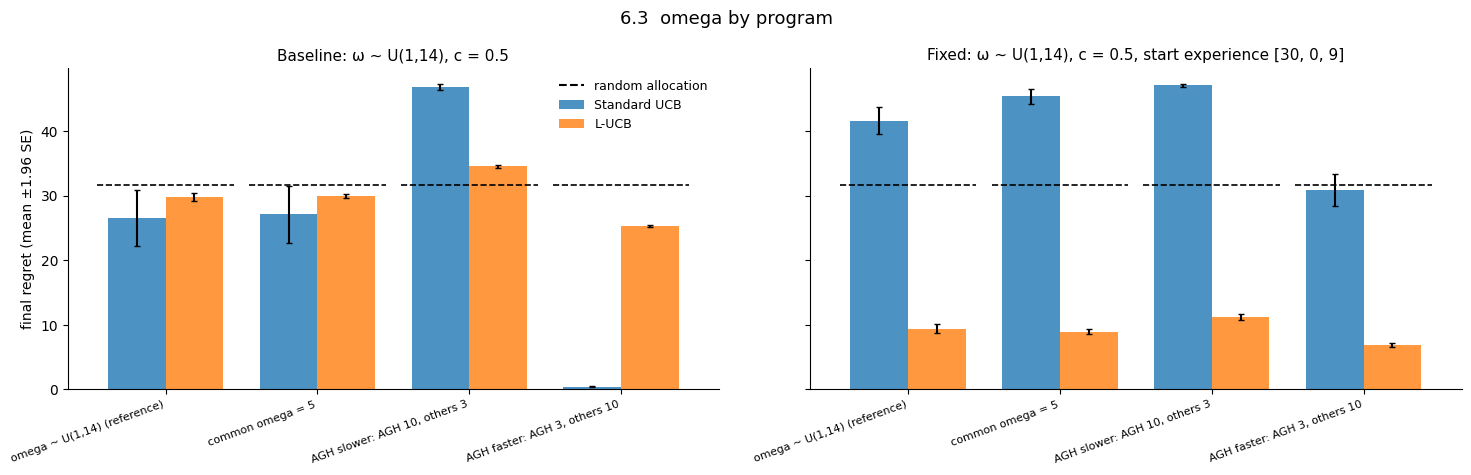

In [17]:
def omegas(u, a, v): return lambda run: np.array([u, a, v], float)

hetero = {  # label: omega_fn (None = the parameter set's own draw, omega ~ U(1,14) per program)
    "omega ~ U(1,14) (reference)":    None,
    "common omega = 5":               omegas(5, 5, 5),
    "AGH slower: AGH 10, others 3":   omegas(3, 10, 3),
    "AGH faster: AGH 3, others 10":   omegas(10, 3, 10),
}
df_h = pd.concat([rb_compare(k, lab, omega_fn=f) for k in SETTINGS for lab, f in hetero.items()])
tab_h = summ(df_h); ALL_RB.append(tab_h.assign(check="6.3 omega by program"))
print("(c and starting experience come from the parameter set; omega comes from the scenario)\n")
print(tab_h.drop(columns=["Standard SD", "L-UCB SD"]).to_string(index=False)); tab_h.to_csv("robustness_6_3_omega_by_program.csv", index=False)
bars(tab_h, "scenario", "6.3  omega by program", "fig_rb_6_3_omega_by_program.png", list(hetero))

### 6.4 Verdict table
One row per scenario. *winner* is the algorithm with significantly lower average regret (more than 1.96 SE, paired); `-` means no significant difference. The conclusion is robust to a check if the winner does not flip across its scenarios.

In [18]:
verdict = pd.concat(ALL_RB, ignore_index=True)
cols = ["check", "scenario", "setting", "Standard regret", "L-UCB regret", "Standard - L-UCB", "SE", "winner", "Standard / random", "L-UCB / random"]
verdict = verdict[cols]
pv = verdict.pivot_table(index=["check", "scenario"], columns="setting", values="winner", aggfunc="first")[["baseline", "fixed"]]
print("Who wins on average regret (baseline | fixed (start experience)):\n"); print(pv.to_string())
print("\nNumber of scenarios won:")
print(verdict.groupby("setting").winner.value_counts().unstack(fill_value=0).to_string())
verdict.to_csv("robustness_all_checks.csv", index=False)

Who wins on average regret (baseline | fixed (start experience)):

setting                                            baseline     fixed
check                scenario                                        
6.1a best program    AGH best (main case)                 -     L-UCB
                     UPMC best                            -  Standard
                     VAPHS best                       L-UCB  Standard
6.1b alpha drawn     n = 100 each                         -     L-UCB
                     n = 200 each                  Standard     L-UCB
                     n = 400 each                  Standard     L-UCB
                     n = 50 each                          -     L-UCB
6.2 horizon          T = 1000                             -     L-UCB
                     T = 200                              -     L-UCB
                     T = 3600                             -     L-UCB
                     T = 500                              -     L-UCB
6.3 omega by program AG